In [62]:
import pandas as pd
import numpy as np
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('future.no_silent_downcasting', True)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor

In [63]:
# Load both datasets
url_1 = 'https://raw.githubusercontent.com/pablo9ja/NRF_work/main/Prostate%20Cancer%202.xlsx'
url_2 = 'https://raw.githubusercontent.com/pablo9ja/NRF_work/main/Prostate%20Data%2022.xlsx'

df = pd.read_excel(url_1)   # shape: (42, 29)
df2 = pd.read_excel(url_2)  # shape: (1013, 30)

# Align df2 to have the same columns as df (in same order)
df2_aligned = df2[df.columns.intersection(df2.columns)]  # retain common columns
df2_aligned = df2_aligned.reindex(columns=df.columns)    # match the exact order of df's columns

# Concatenate the two DataFrames
df3 = pd.concat([df, df2_aligned], ignore_index=True)
print(df.shape)
print(df2.shape)
print(df3.shape)


(42, 29)
(1013, 30)
(1055, 29)


In [64]:
df.columns

Index(['S/N', 'NAMES', 'AGE', 'GENDER', 'HOSPITAL NO', 'LAB NO', 'STATE',
       'MARITAL STATUS', 'HIGHEST LEVEL OF EDUCATION', 'OCCUPATION',
       'MONTHLY INCOME', 'ETHNIC GROUP', 'WHO MADE YOU SEEK MEDICAL HELP',
       'SYMPTIONS', 'MEDICAL CONDITIONS', 'HEIGHT (CM)', 'WEIGHT',
       'ENGAGEMENT IN PHYSICAL EXERCISE', 'OVERALL DIET',
       'MEAL(S) TAKEN IN A DAY', 'DO YOU CONSUME ALCOHOL?', 'DO YOU SMOKE?',
       'HOW DO YOU RATE YOUR STRESS LEVEL?',
       'DO YOU ENGAGE IN ACTIVITIES TO MANAGE STRESS?',
       'HOURS OF SLEEP PER NIGHT', 'PSA (ng/ml)', 'DRE', 'BIOPSY CORES',
       'FINDINGS'],
      dtype='object')

In [65]:
df2.columns

Index(['NAMES', 'AGE', 'GENDER', 'HOSPITAL NO', 'LAB NO', 'STATE',
       'MARITAL STATUS', 'HIGHEST LEVEL OF EDUCATION', 'OCCUPATION',
       'MONTHLY INCOME', 'ETHNIC GROUP', 'WHO MADE YOU SEEK MEDICAL HELP',
       'SYMPTIONS', 'MEDICAL CONDITIONS', 'HEIGHT (CM)', 'WEIGHT',
       'ENGAGEMENT IN PHYSICAL EXERCISE', 'OVERALL DIET',
       'MEAL(S) TAKEN IN A DAY', 'DO YOU CONSUME ALCOHOL?', 'DO YOU SMOKE?',
       'HOW DO YOU RATE YOUR STRESS LEVEL?',
       'DO YOU ENGAGE IN ACTIVITIES TO MANAGE STRESS?',
       'HOURS OF SLEEP PER NIGHT', 'PSA (ng/ml)', 'DRE', 'BIOPSY CORES',
       'FINDINGS', 'Unnamed: 28', 'Unnamed: 29'],
      dtype='object')

In [66]:
df3.columns

Index(['S/N', 'NAMES', 'AGE', 'GENDER', 'HOSPITAL NO', 'LAB NO', 'STATE',
       'MARITAL STATUS', 'HIGHEST LEVEL OF EDUCATION', 'OCCUPATION',
       'MONTHLY INCOME', 'ETHNIC GROUP', 'WHO MADE YOU SEEK MEDICAL HELP',
       'SYMPTIONS', 'MEDICAL CONDITIONS', 'HEIGHT (CM)', 'WEIGHT',
       'ENGAGEMENT IN PHYSICAL EXERCISE', 'OVERALL DIET',
       'MEAL(S) TAKEN IN A DAY', 'DO YOU CONSUME ALCOHOL?', 'DO YOU SMOKE?',
       'HOW DO YOU RATE YOUR STRESS LEVEL?',
       'DO YOU ENGAGE IN ACTIVITIES TO MANAGE STRESS?',
       'HOURS OF SLEEP PER NIGHT', 'PSA (ng/ml)', 'DRE', 'BIOPSY CORES',
       'FINDINGS'],
      dtype='object')

In [67]:
for x in df3.columns:
    if df3[x].isna().sum() >200:
        print(f"{x}: {df3[x].isna().sum()} missing values")


S/N: 1013 missing values
MEDICAL CONDITIONS: 973 missing values
ENGAGEMENT IN PHYSICAL EXERCISE: 335 missing values
PSA (ng/ml): 426 missing values
DRE: 843 missing values


In [68]:
extra_columns = df2.columns.difference(df.columns)
print("Extra columns:", extra_columns)
missing_percentage = df2[extra_columns].isna().mean() * 100  # Calculate percentage of missing values

columns_missing_50_plus = missing_percentage[missing_percentage > 50]
print("Columns with more than 50% missing values:", columns_missing_50_plus)


Extra columns: Index(['Unnamed: 28', 'Unnamed: 29'], dtype='object')
Columns with more than 50% missing values: Unnamed: 28    92.201382
Unnamed: 29    99.901283
dtype: float64


In [69]:
#df3 = pd.read_excel('merged_prostrate_cancer_data.xlsx')
#df3.head(2)

In [70]:
# Clean column names
df3.columns = (
    df3.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^\w\s]', '', regex=True)
    .str.replace(r'\s+', '_', regex=True)
)
df3.head(2)

,sn,names,age,gender,hospital_no,lab_no,state,marital_status,highest_level_of_education,occupation,monthly_income,ethnic_group,who_made_you_seek_medical_help,symptions,medical_conditions,height_cm,weight,engagement_in_physical_exercise,overall_diet,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,how_do_you_rate_your_stress_level,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,psa_ngml,dre,biopsy_cores,findings
0,1.0,ALIYU USMAN,73.0,MALE,NaN,NaN,SOKOTO,MARRIED,TERTIARY,SKILLED,LESS THAN 70000 NAIRA,HAUSA,FAMILY HISTORY; MOTHER'S SISTER WITH BREAST CA...,"DRIBBLING OF URINE, INCOMPLETE VOIDING, LACK O...","HYPERTENSION, DEPRESSION",153,53,Moderate,High in carbohydrate and processed foods,2,NO,NO,Moderate,No,7 to 8 hours,12.23,"ENLARGED, MEDIAN GROVE",4.0,Prostrate (biopsy)- Nodular hyperplasia
1,2.0,SAIDU ABUBAKAR,58.0,MALE,NaN,900624,SOKOTO,MARRIED,TERTIARY,UNSKILLED,LESS THAN 70000 NAIRA,HAUSA,MY DOCTOR SUGGESTED THAT I GO FOR A SCREENING;...,"FREQUENT URINATION, NOCTURIA, LACK OF RECTION",HYPERTENSION,155,51,Little,High in carbohydrate and processed foods,2,NO,NO,Moderate,Yes,More than 8 hours,19.07,NaN,NaN,Prostrate (biopsy)- Nodular hyperplasia


In [71]:
df3['monthly_income'].value_counts()

monthly_income
Less than ₦70,000         734
₦80,000 to ₦150,000       204
More than ₦150,000         75
LESS THAN 70000 NAIRA      29
80000-150000 NAIRA         12
MORE THAN 160000 NAIRA      1
Name: count, dtype: int64

In [72]:
df3['psa_ngml'].isna().sum()

np.int64(426)

In [73]:
def clean_healthcare_data(df):
    # avoid SettingWithCopyWarning
    df = df.copy()

    # Drop columns with more than 30% missing values
    missing_threshold = int(0.7 * len(df))
    df = df.dropna(axis=1, thresh=missing_threshold)

    # Drop specific irrelevant columns if they exist
    columns_to_drop = ['sn','hospital_no', 'names', 'lab_no', 'gender']
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

    # Forward fill and backward fill missing values
    df = df.ffill().bfill()

    # Convert all string values in the DataFrame to lowercase
    df = df.apply(lambda col: col.map(lambda x: x.lower() if isinstance(x, str) else x))

    df['bmi'] = df['weight'] / (df['height_cm']/100)**2

    # Clean specific columns only if they exist
    if 'engagement_in_physical_exercise' in df.columns:
        df['engagement_in_physical_exercise'] = df['engagement_in_physical_exercise'].str.strip()

    if 'age' in df.columns:
        df['age'] = pd.to_numeric(df['age'], errors='coerce').fillna(0).astype(int)

    if 'highest_level_of_education' in df.columns:
      df['highest_level_of_education'] = (
        df['highest_level_of_education']
        .replace({
            'non-formal': 'non-formal',
            'non formal education': 'non-formal',
            'secondary level education': 'secondary',
            'primary level education': 'primary'
        }))

    if 'height_cm' in df.columns:
        df['height_cm'] = pd.to_numeric(
            df['height_cm'].astype(str)
            .str.replace(r'\s+', '', regex=True)
            .str.replace('cm', '', regex=True),
            errors='coerce'
        )

    if 'weight' in df.columns:
        df['weight'] = pd.to_numeric(
            df['weight'].astype(str)
            .str.replace(r'\s+', '', regex=True)
            .str.replace('kg', '', regex=True),
            errors='coerce'
        )

    if 'meals_taken_in_a_day' in df.columns:
        meal_mapping = {'above': 5}
        meals = df['meals_taken_in_a_day'].replace(meal_mapping)
        df['meals_taken_in_a_day'] = pd.to_numeric(
            meals.astype(str),
            errors='coerce'
        ).infer_objects(copy=False)

    if 'hours_of_sleep_per_night' in df.columns:
        sleep_mapping = {
            'less than 5 hours': 4,
            '5 to 6 hours': 5.5,
            '7 to 8 hours': 7.5,
            'more than 8 hours': 9
        }
        sleep = df['hours_of_sleep_per_night'].replace(sleep_mapping)
        df['hours_of_sleep_per_night'] = pd.to_numeric(
            sleep.astype(float),
            errors='coerce'
        ).infer_objects(copy=False)

    if 'monthly_income' in df.columns:
        # Standardize the income strings
        df['monthly_income'] = (
            df['monthly_income']
            .astype(str)
            .str.lower()
            .str.strip()
            .str.replace(r'[,\s₦]+', '', regex=True)
            .str.replace('to', '-')
            .str.replace('andabove', '+')
            .str.replace('morethan', '>')
            .str.replace('lessthan', '<')
            .str.replace('naira', '')
            .str.replace(' ', '')
        )

        # Create mapping for income ranges to average values
        income_map = {
            '<70000': 35000,          # Average for < ₦70,000
            '80000-150000': 115000,   # Average for ₦80,000-₦150,000
            '>150000': 160000,        # Average for > ₦150,000
            '>160000': 170000,        # Specific case from your data
            '10000-30000': 20000,
            '31000-50000': 40500,
            '51000-70000': 60500,
            '71000-90000': 80500,
            '91000+': 95000,
            '<10000': 5000,
            'none': 0,
            '0': 0
        }

        # Apply the mapping
        df['monthly_income'] = df['monthly_income'].replace(income_map)

        # Convert to numeric (coerce invalid values to NaN)
        df['monthly_income'] = pd.to_numeric(df['monthly_income'], errors='coerce')

        if 'who_made_you_seek_medical_help' in df.columns:
          df['who_made_you_seek_medical_help'] = df['who_made_you_seek_medical_help'].replace({
          'family or friends': 'family or friends',
          'self': 'self',
          'doctor': 'doctor',
          'my doctor suggested that i go for a screening': 'doctor',
          'my family or friends suggested that i go for a screening': 'family or friends',
          'my doctor suggested that i go for a screening; no history': 'doctor',
          'i was concerned about some unusual symptoms i was having, so i went to the clinic': 'self',
          'family history; mother\'s sister with breast cancer': 'self',
          'my doctor suggested that i go for a screening; yes, family history about 15 members': 'doctor',
          'my doctor suggested that i go for a screening; history of cancer from mother (breast cancer)': 'doctor',
          'my doctor suggested that i go for a screening; history of cancer from mother (breasr cancer)':'doctor'
    })



    return df

# Apply the cleaning function
df3 = clean_healthcare_data(df3)

In [74]:
df3.columns

Index(['age', 'state', 'marital_status', 'highest_level_of_education',
       'occupation', 'monthly_income', 'ethnic_group',
       'who_made_you_seek_medical_help', 'symptions', 'height_cm', 'weight',
       'overall_diet', 'meals_taken_in_a_day', 'do_you_consume_alcohol',
       'do_you_smoke', 'how_do_you_rate_your_stress_level',
       'do_you_engage_in_activities_to_manage_stress',
       'hours_of_sleep_per_night', 'biopsy_cores', 'findings', 'bmi'],
      dtype='object')

In [75]:
import pandas as pd
import re

# Define typo corrections
corrections = {
    r'\bfreuency\b': 'frequency',
    r'\burgrncy\b': 'urgency',
    r'\bnoctoria\b': 'nocturia',
    r'\bhaemalistura\b': 'haematuria',
    r'\burin\b': 'urine',
    r'\bpaain\b': 'pain',
    r'\bretentiom\b': 'retention',
    r'\bdysuris\b': 'dysuria',
    r'\blurt\b': 'luts',
    r'\blut\b': 'luts',
}

# Replace typos and clean punctuation
def clean_symptoms(text):
    if pd.isna(text):
        return ""

    # Lowercase
    text = text.lower()

    # Fix typos
    for typo, correct in corrections.items():
        text = re.sub(typo, correct, text)

    # Standardize delimiters (commas, semicolons, slashes)
    text = re.sub(r'[\n;/?]+', ',', text)  # Replace newline, semicolon, slash with comma
    text = re.sub(r'\s*,\s*', ', ', text)  # clean up spacing around commas
    text = re.sub(r'\s+', ' ', text)  # Normalize spacing

    return text.strip()

df3['symptions'] = df3['symptions'].apply(clean_symptoms)


In [76]:
df3.head(2)

,age,state,marital_status,highest_level_of_education,occupation,monthly_income,ethnic_group,who_made_you_seek_medical_help,symptions,height_cm,weight,overall_diet,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,how_do_you_rate_your_stress_level,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,biopsy_cores,findings,bmi
0,73,sokoto,married,tertiary,skilled,35000,hausa,self,"dribbling of urine, incomplete voiding, lack o...",153,53,high in carbohydrate and processed foods,2,no,no,moderate,no,7.5,4.0,prostrate (biopsy)- nodular hyperplasia,22.640865
1,58,sokoto,married,tertiary,unskilled,35000,hausa,doctor,"frequent urination, nocturia, lack of rection",155,51,high in carbohydrate and processed foods,2,no,no,moderate,yes,9.0,4.0,prostrate (biopsy)- nodular hyperplasia,21.227888


In [58]:
import numpy as np

def categorize_symptoms(text):
    if pd.isna(text) or text.strip() == "":
        return 'unspecified'

    text = text.lower()  # for uniform matching

    if 'luts' in text:
        return 'LUTS'
    elif 'frequent urination' in text or 'nocturia' in text or 'urinary' in text:
        return 'Painful Urination'
    elif 'dysuria' in text or 'pain' in text or 'difficulty' in text:
        return 'Painful Urination'
    elif 'dribbling' in text or 'incomplete voiding' in text:
        return 'Obstructive Symptoms'
    elif 'hesitancy' in text:
        return 'Hesitancy'
    elif 'blood' in text or 'haematuria' in text or 'adenocrcinoma' in text:
        return 'Hematuria'
    elif 'inability to walk' in text or 'weakness' in text or 'paraparesis' in text:
        return 'Neurological Impairment'
    elif 'erection' in text or 'ejaculation' in text:
        return 'Sexual Dysfunction'
    elif 'bph' in text:
        return 'BPH'
    elif 'retention' in text or 'unable to pass urine' in text or 'frequency' in text:
        return 'Painful Urination'
    else:
        return 'others'

df3['symptions'] = df3['symptions'].apply(categorize_symptoms)
# print(df3[df3['symptom_category'] == 'Other']['symptions'].unique())
df3.head()

,sn,names,age,gender,hospital_no,lab_no,state,marital_status,highest_level_of_education,occupation,monthly_income,ethnic_group,who_made_you_seek_medical_help,symptions,medical_conditions,height_cm,weight,engagement_in_physical_exercise,overall_diet,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,how_do_you_rate_your_stress_level,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,psa_ngml,dre,biopsy_cores,findings
0,1.0,ALIYU USMAN,73.0,MALE,NaN,NaN,SOKOTO,MARRIED,TERTIARY,SKILLED,LESS THAN 70000 NAIRA,HAUSA,FAMILY HISTORY; MOTHER'S SISTER WITH BREAST CA...,Obstructive Symptoms,"HYPERTENSION, DEPRESSION",153,53,Moderate,High in carbohydrate and processed foods,2,NO,NO,Moderate,No,7 to 8 hours,12.23,"ENLARGED, MEDIAN GROVE",4.0,Prostrate (biopsy)- Nodular hyperplasia
1,2.0,SAIDU ABUBAKAR,58.0,MALE,NaN,900624,SOKOTO,MARRIED,TERTIARY,UNSKILLED,LESS THAN 70000 NAIRA,HAUSA,MY DOCTOR SUGGESTED THAT I GO FOR A SCREENING;...,Painful Urination,HYPERTENSION,155,51,Little,High in carbohydrate and processed foods,2,NO,NO,Moderate,Yes,More than 8 hours,19.07,NaN,NaN,Prostrate (biopsy)- Nodular hyperplasia
2,3.0,BUNU SHEHU,88.0,MALE,NaN,NaN,SOKOTO,MARRIED,PRIMARY LEVEL EDUCATION,SKILLED,80000-150000 NAIRA,HAUSA,MY DOCTOR SUGGESTED THAT I GO FOR A SCREENING;...,Painful Urination,NaN,163,49,Little,High in carbohydrate and processed foods,3,NO,NO,High,No,5 to 6 hours,NaN,NaN,NaN,Prostrate (biopsy)- Nodular hyperplasia
3,4.0,SAMRA ABUBAKAR,76.0,MALE,NaN,696401,SOKOTO,MARRIED,SECONDARY LEVEL EDUCATION,UNSKILLED,LESS THAN 70000 NAIRA,HAUSA,MY DOCTOR SUGGESTED THAT I GO FOR A SCREENING;...,Painful Urination,NaN,165,57,Moderate,High in carbohydrate and processed foods,4,NO,NO,High,No,5 to 6 hours,14.651,"ENLARGE, HARD, NODULE",4.0,Prostrate (biopsy)- Nodular hyperplasia
4,5.0,NaN,63.0,MALE,NaN,699768,SOKOTO,MARRIED,NON FORMAL EDUCATION,UNSKILLED,LESS THAN 70000 NAIRA,HAUSA,MY DOCTOR SUGGESTED THAT I GO FOR A SCREENING;...,Painful Urination,NaN,161,55,Moderate,High in carbohydrate and processed foods,Above,NO,NO,Moderate,No,7 to 8 hours,7.07,NaN,NaN,Prostrate tissue (biopsy)- nodular hyperplasia


In [77]:
data = df3['findings']

# Define categorization rules
categories = {
    'Benign': [
        'nodular hyperplasia', 'benign prostatic hyperplasia','benign nodular hyperplasia',
        'prostatitis', 'fibromuscular', 'chronic inflammation', 'schistosomiasis', 'low grade pin',
        'hyphasia','no pathology','inadequate','suspicious','loer grade pin','fibromiscular',
        'non-specific chronic inflammation','dystrophic calcification','schistosomal fibrosis','schortosomasir',
        'consistant with nodular hyperplasia'
    ],
    'Malignant': [
        'adenocarcinoma','carcinoma','gleason','metastatic','squamn','neoplasm','neopin', 'high grade',
        'urothelial carcinoma','invacive','prostate cancer', 'cloacogenesis','intraspiral neopin','intracellular neoplasm'
    ],
    'Inconclusive': [
        'inadequate', 'no pathology', 'suspicious', 'specimen cell corcium', 'autologous', 'detrufor hypertrophy',
        'absulute hypertrophy','confirmed','orchidectory','nostetic','prostetic','shows','luts','culminating',
        'elevated psa',' ','-'
    ]
}

# Function to categorize a single finding
def categorize_finding(findings):
    finding_lower = findings.lower()
    for category, keywords in categories.items():
        for keyword in keywords:
            if keyword in finding_lower:
                return category
    return 'Inconclusive'

# Categorize all findings and add the category to the DataFrame
#df3['categories'] = df3['findings'].apply(categorize_finding)
df3['findings'] = df3['findings'].apply(categorize_finding)

# Drop rows where 'findings' contain 'Inconclusive' (case insensitive)
df3 = df3[~df3['findings'].str.contains('Inconclusive', case=False, na=False)]
df3.reset_index(drop=True, inplace=True)

df3['findings'].unique()

array(['Benign', 'Malignant'], dtype=object)

In [59]:
df3['findings'].value_counts()

findings
Prostate (Biopsy) - Nodular hyperplasia                                                                                          176
POSTATE  BIOPSY NODULAR HYPERPLASIA                                                                                              117
PROSTATE BIOPSY-NODULAR HYPERPLASIA                                                                                               78
Nodular Hyperplasia                                                                                                               73
Prostrate (biopsy)- Nodular hyperplasia                                                                                           58
nodular Hyperplasia                                                                                                               48
Adenocarcinoma                                                                                                                    20
Prostate (Biopsy) - Nodular hyperplasia with prostatitis    

In [78]:
df3.shape

(1021, 21)

# Feature Engineering

In [41]:
# Create BMI feature from height and weight
bmi = df3['weight'] / (df3['height_cm']/100)**2
income_bins = [0, 10000, 30000, 50000, 70000, 90000, float('inf')]
income_labels = ['very low', 'low', 'medium', 'high', 'very high', 'extremely high']

# Create income groups without NaN values
income_group = pd.cut(df3['monthly_income'],
                            bins=income_bins,
                            labels=income_labels,
                            include_lowest=True)

In [42]:

# Load your DataFrame (assume it's called df)
summary = df3.groupby(['do_you_consume_alcohol', 'do_you_smoke'])['findings'].value_counts().unstack().fillna(0)
print(summary)


findings                                 0      1
do_you_consume_alcohol do_you_smoke              
0                      0             526.0  230.0
                       1             136.0   68.0
1                      0              37.0   18.0
                       1               6.0    0.0


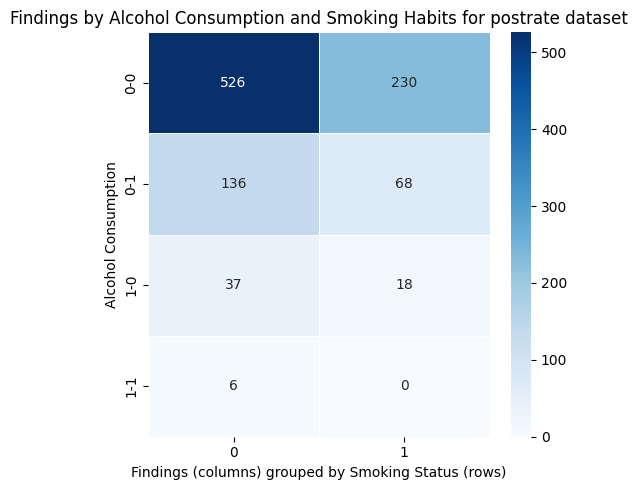

In [43]:
# Plot the heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(summary, annot=True, fmt='.0f', cmap='Blues', linewidths=.5)

plt.title('Findings by Alcohol Consumption and Smoking Habits for postrate dataset')
plt.ylabel('Alcohol Consumption')
plt.xlabel('Findings (columns) grouped by Smoking Status (rows)')

plt.tight_layout()
plt.show()


C:\Users\lenovo\AppData\Local\Temp\ipykernel_11828\160831404.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(str)



=== DATA DIAGNOSTICS ===

Postrate Cancer Risk Distribution:
cancer_risk
0    1021
Name: count, dtype: int64

Missing Values:
age                                                      0
monthly_income                                           0
height_cm                                                0
weight                                                   0
meals_taken_in_a_day                                     0
do_you_consume_alcohol                                   0
do_you_smoke                                             0
do_you_engage_in_activities_to_manage_stress             0
hours_of_sleep_per_night                                 0
biopsy_cores                                             0
findings                                                 0
bmi                                                      0
state_adamawa                                            0
state_akwa ibom                                          0
state_anambra                                  

c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_stats_py.py:5657: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


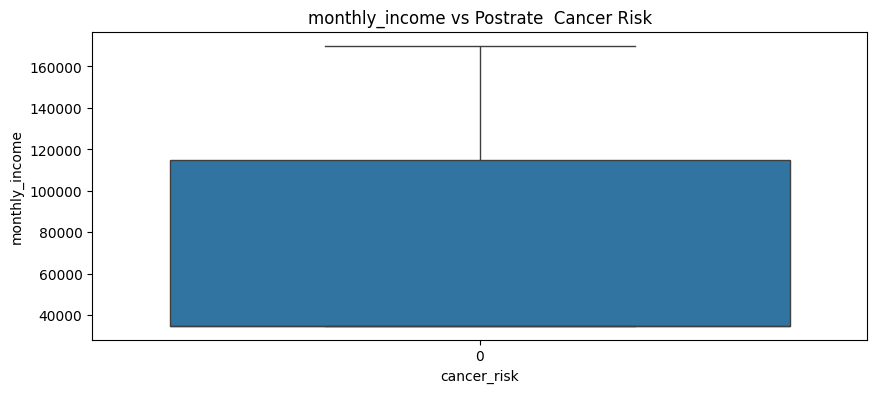

c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_stats_py.py:5657: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)



hours_of_sleep_per_night:
Correlation = nan, p-value = nan


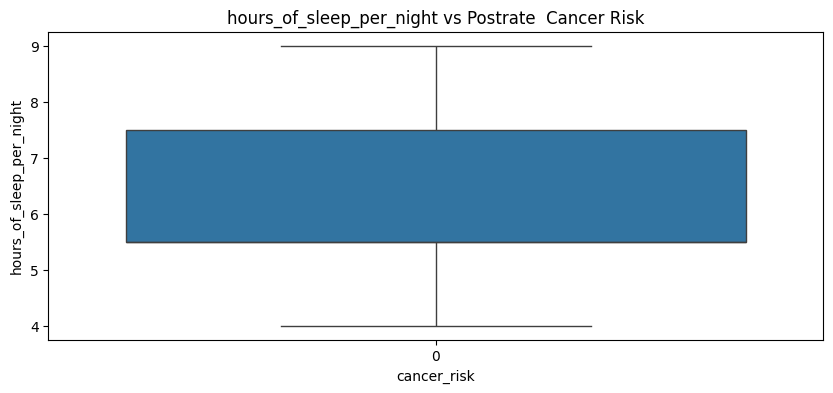

c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_stats_py.py:5657: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)



bmi:
Correlation = nan, p-value = nan


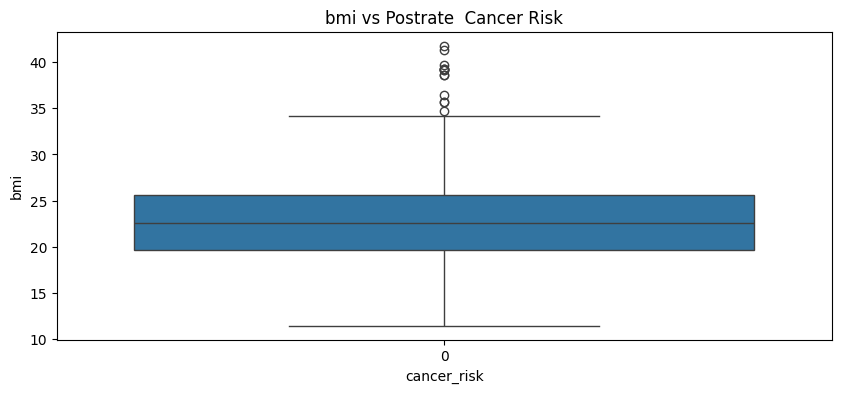

c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_stats_py.py:5657: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)



age:
Correlation = nan, p-value = nan


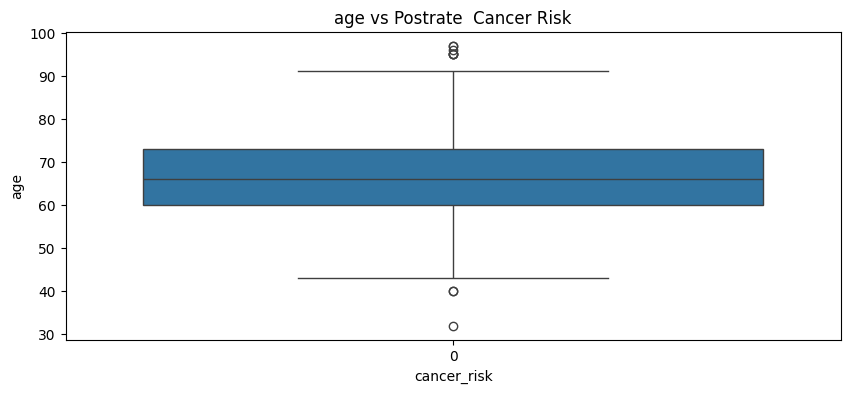


=== ADVANCED ANALYSIS ===

Analysis complete!


In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Load and prepare data
def load_data(df):
    # Convert all columns to string type for safety
    df = df.applymap(str)
    
    # Create cancer_risk target (1=malignant, 0=benign)
    df['cancer_risk'] = df['findings'].str.lower().str.contains('cancer').astype(int)
    
    # Clean continuous variables
    cont_vars = ['monthly_income', 'hours_of_sleep_per_night', 'bmi', 'age']
    for var in cont_vars:
        if var in df.columns:
            df[var] = pd.to_numeric(df[var], errors='coerce')
    
    return df

# Diagnostic checks
def run_diagnostics(df):
    print("\n=== DATA DIAGNOSTICS ===")
    
    # 1. Check target distribution
    print("\nPostrate Cancer Risk Distribution:")
    print(df['cancer_risk'].value_counts(dropna=False))
    
    # 2. Check missing values
    print("\nMissing Values:")
    print(df.isna().sum())
    
    # 3. Check categorical variables
    cat_vars = ['overall_diet', 'do_you_consume_alcohol', 
               'do_you_smoke', 'how_do_you_rate_your_stress_level']
    print("\nCategorical Value Counts:")
    for var in cat_vars:
        if var in df.columns:
            print(f"\n{var}:")
            print(df[var].value_counts(dropna=False))
    
    # 4. Check continuous variables
    cont_vars = ['monthly_income', 'hours_of_sleep_per_night', 'bmi', 'age']
    print("\nContinuous Variable Summary:")
    print(df[cont_vars].describe())

# Lifestyle correlation analysis
def analyze_lifestyle(df):
    print("\n=== LIFESTYLE FACTOR ANALYSIS ===")
    
    # Categorical variables
    cat_vars = ['overall_diet', 'do_you_consume_alcohol', 
               'do_you_smoke', 'how_do_you_rate_your_stress_level']
    
    for var in cat_vars:
        if var in df.columns:
            # Create contingency table
            table = pd.crosstab(df[var], df['cancer_risk'])
            
            # Skip if no variation
            if table.shape[0] < 2 or table.shape[1] < 2:
                print(f"\n{var}: Cannot test - insufficient variation")
                continue
                
            # Chi-square test
            chi2, p, dof, _ = chi2_contingency(table)
            print(f"\n{var}:")
            print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}")
            print("Contingency Table:")
            print(table)
            
            # Visualize
            plt.figure(figsize=(10,4))
            sns.countplot(data=df, x=var, hue='cancer_risk')
            plt.title(f"{var} vs Postrate Cancer Risk")
            plt.show()
    
    # Continuous variables
    cont_vars = ['monthly_income', 'hours_of_sleep_per_night', 'bmi', 'age']
    for var in cont_vars:
        if var in df.columns:
            # Remove missing values
            clean_df = df.dropna(subset=[var, 'cancer_risk'])
            
            # Skip if no variation
            if clean_df[var].nunique() < 2:
                print(f"\n{var}: Cannot test - no variation")
                continue
                
            # Point-biserial correlation
            corr, p = pointbiserialr(clean_df[var], clean_df['cancer_risk'])
            print(f"\n{var}:")
            print(f"Correlation = {corr:.2f}, p-value = {p:.4f}")
            
            # Visualize
            plt.figure(figsize=(10,4))
            sns.boxplot(data=clean_df, x='cancer_risk', y=var)
            plt.title(f"{var} vs Postrate  Cancer Risk")
            plt.show()

# Advanced analysis
def advanced_analysis(df):
    print("\n=== ADVANCED ANALYSIS ===")
    
    # 1. Symptom analysis
    if 'symptions' in df.columns:
        df['urinary_symptoms'] = df['symptions'].str.lower().str.contains(
            'dribbling|nocturia|frequent urination', regex=True).astype(int)
        
        # Check symptom prevalence
        print("\nUrinary Symptom Prevalence:")
        print(df['urinary_symptoms'].value_counts())
        
        # Correlation with cancer
        if 'cancer_risk' in df.columns:
            table = pd.crosstab(df['urinary_symptoms'], df['cancer_risk'])
            chi2, p, _, _ = chi2_contingency(table)
            print(f"\nUrinary Symptoms vs Postrate  Cancer: Chi2={chi2:.2f}, p={p:.4f}")
    
    # 2. Predictive modeling
    try:
        features = ['age', 'bmi', 'urinary_symptoms'] 
        features = [f for f in features if f in df.columns]
        
        if features and 'cancer_risk' in df.columns:
            X = df[features].fillna(df[features].median())
            y = df['cancer_risk']
            
            if y.nunique() > 1:
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=0.3, random_state=42)
                
                model = RandomForestClassifier()
                model.fit(X_train, y_train)
                
                print("\nPrediction Model Performance:")
                print(classification_report(y_test, model.predict(X_test)))
                
                print("\nFeature Importances:")
                for name, imp in zip(features, model.feature_importances_):
                    print(f"{name}: {imp:.2f}")
    except Exception as e:
        print(f"\nModeling failed: {str(e)}")

# Main execution
if __name__ == "__main__":
    # Load your data
    # df = pd.read_csv('your_data.csv')  # Uncomment to load from file
    # Or use your existing DataFrame:
    df = df3.copy()  # Replace df3 with your actual DataFrame name
    
    # Clean and prepare data
    df = load_data(df)
    
    # Run diagnostics
    run_diagnostics(df)
    
    # Core analysis
    analyze_lifestyle(df)
    
    # Advanced analysis
    advanced_analysis(df)
    
    print("\nAnalysis complete!")

In [45]:
state_counts = df3['state'].value_counts()

# Create bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=state_counts.values,
            y=state_counts.index,
            hue=state_counts.index,  # Added hue
            palette='viridis',
            legend=False)  # Disable legend since we don't need it

plt.title('Distribution of Cancer Cases by State', pad=20)
plt.xlabel('Number of Cases')
plt.ylabel('State')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels
for i, v in enumerate(state_counts.values):
    plt.text(v + 0.2, i, str(v), color='black', va='center')

plt.tight_layout()
plt.show()

KeyError: 'state'

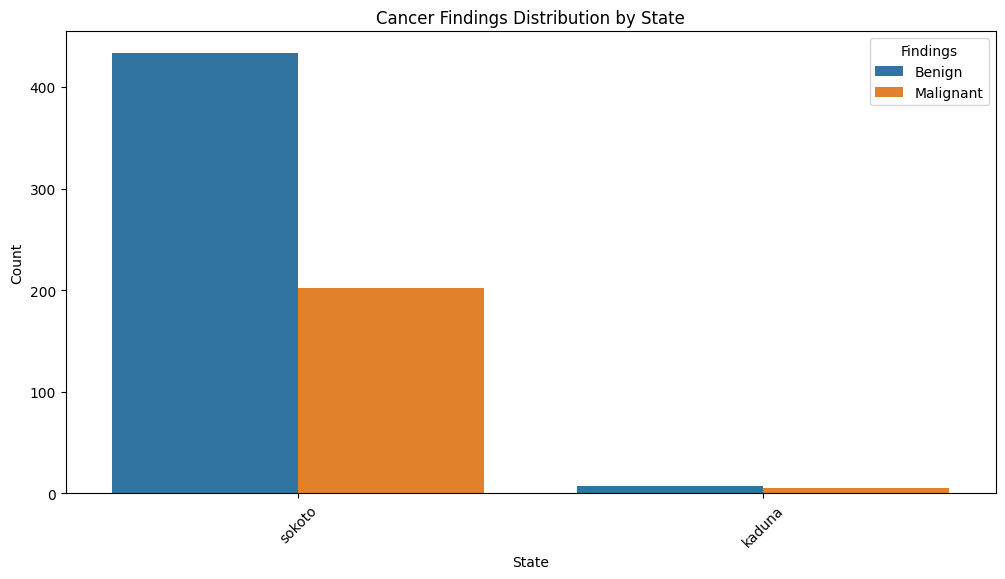

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df3, x='state', hue='findings', order=df3['state'].head(20).value_counts().index)
plt.title('Cancer Findings Distribution by State')
plt.xlabel('State')
plt.ylabel('Count')
plt.legend(title='Findings')
plt.xticks(rotation=45)
plt.show()

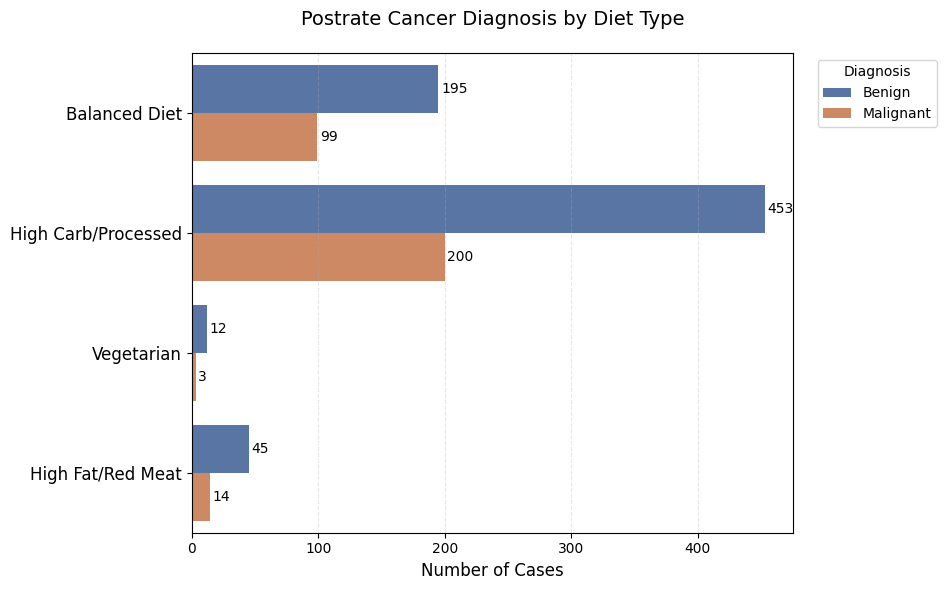

In [ ]:
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# Define diet labels
diet_labels = {
    'balance': 'Balanced Diet',
    'high in carbohydrate and processed foods': 'High Carb/Processed',
    'vegetarian': 'Vegetarian',
    'high in fat and red meat': 'High Fat/Red Meat'
}

# Define complete findings palette
findings_palette = {
    'Benign': '#4c72b0',
    'Malignant': '#dd8452',
    'Inconclusive': '#7f7f7f'
}

# Create plot
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df3,
    y='overall_diet',
    hue='findings',
    order=list(diet_labels.keys()),
    palette=findings_palette
)

# Customize y-axis labels
plt.yticks(
    ticks=range(len(diet_labels)),
    labels=[diet_labels[d] for d in diet_labels.keys()],
    fontsize=12
)

# Add titles and labels
plt.title('Postrate Cancer Diagnosis by Diet Type', pad=20, fontsize=14)
plt.xlabel('Number of Cases', fontsize=12)
plt.ylabel('')
plt.legend(title='Diagnosis', bbox_to_anchor=(1.25, 1))

# Add count labels
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=2, fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

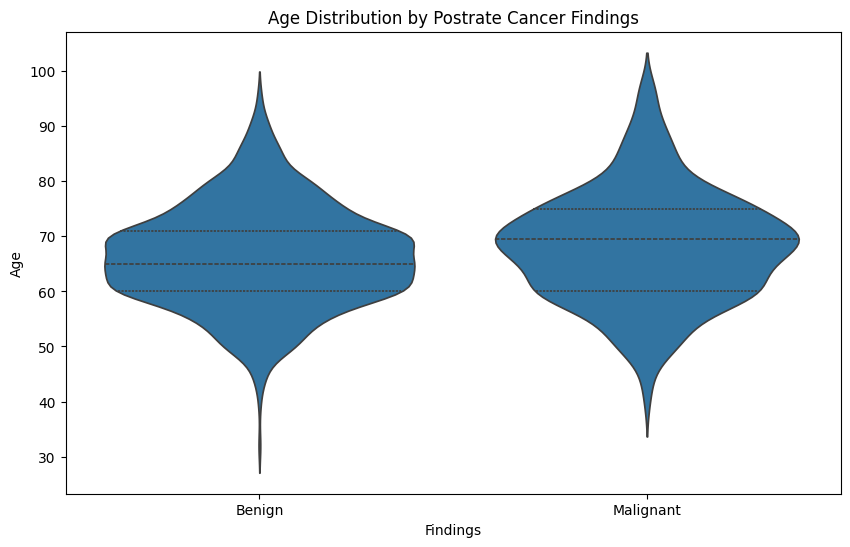

In [28]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df3, x='findings', y='age', inner='quartile')
plt.title('Age Distribution by Postrate Cancer Findings')
plt.xlabel('Findings')
plt.ylabel('Age')
plt.show()

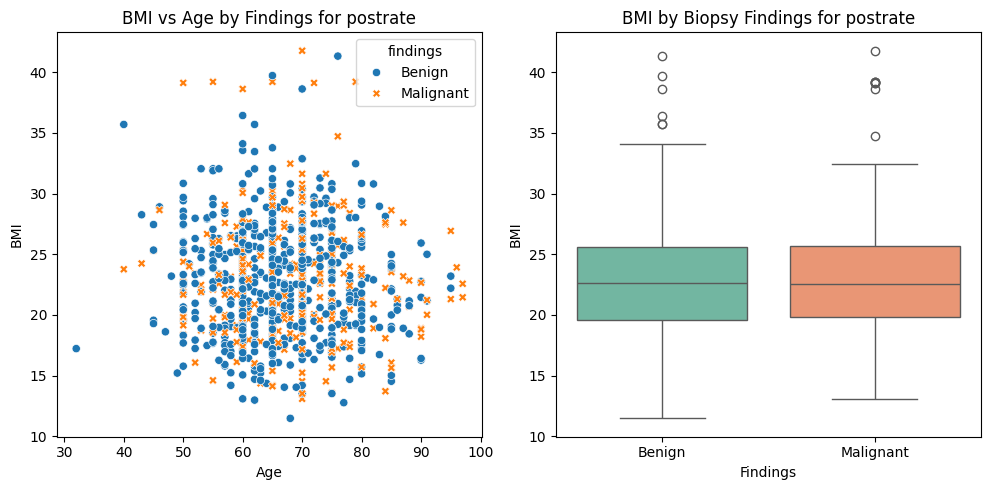

In [29]:
plt.figure(figsize=(15, 5))

# BMI vs Age
plt.subplot(1, 3, 1)
sns.scatterplot(x='age', y='bmi', data=df3, hue='findings', style='findings')
plt.title('BMI vs Age by Findings for postrate')
plt.xlabel('Age')
plt.ylabel('BMI')

# BMI vs Findings (target variable)
plt.subplot(1, 3, 2)
sns.boxplot(x='findings', y='bmi', data=df3,
            hue='findings', palette='Set2', legend=False)
plt.title('BMI by Biopsy Findings for postrate')
plt.xlabel('Findings')
plt.ylabel('BMI')

plt.tight_layout()
plt.show()

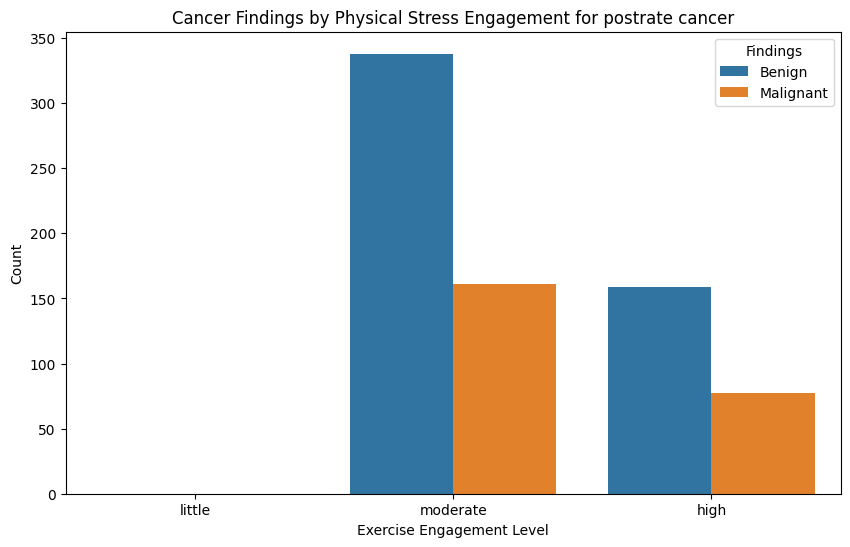

In [30]:

plt.figure(figsize=(10,6))
sns.countplot(data=df3, x='how_do_you_rate_your_stress_level', hue='findings',
             order=['little', 'moderate', 'high'])
plt.title('Cancer Findings by Physical Stress Engagement for postrate cancer')
plt.xlabel('Exercise Engagement Level')
plt.ylabel('Count')
plt.legend(title='Findings')
plt.show()

# Train a Baseline Model

# model preparation


In [31]:
df3.head(2)

,age,state,marital_status,highest_level_of_education,occupation,monthly_income,ethnic_group,who_made_you_seek_medical_help,symptions,height_cm,weight,overall_diet,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,how_do_you_rate_your_stress_level,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,biopsy_cores,findings,bmi
0,73,sokoto,married,tertiary,skilled,35000,hausa,self,Obstructive Symptoms,153,53,high in carbohydrate and processed foods,2,no,no,moderate,no,7.5,4.0,Benign,22.640865
1,58,sokoto,married,tertiary,unskilled,35000,hausa,doctor,Painful Urination,155,51,high in carbohydrate and processed foods,2,no,no,moderate,yes,9.0,4.0,Benign,21.227888


In [32]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

binary_cols = ['do_you_consume_alcohol', 'do_you_smoke', 'do_you_engage_in_activities_to_manage_stress']
for col in binary_cols:
    df3[col] = LabelEncoder().fit_transform(df3[col])


categorical_cols = [
    col for col in df3.select_dtypes(include=['object', 'category']).columns
    if col not in binary_cols and col != 'findings'
]
df3 = pd.get_dummies(df3, columns=categorical_cols, drop_first=True)

df3['findings'] = LabelEncoder().fit_transform(df3['findings'])

numerical_cols = df3.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical columns:", len(numerical_cols))
print("Final DataFrame shape:", df3.shape)

original_features = [
    'age', 'monthly_income', 'height_cm', 'weight', 'bmi',
    'meals_taken_in_a_day', 'hours_of_sleep_per_night', 'biopsy_cores'
]
print("\nFeature Inclusion Check:")
for feat in original_features:
    print(f"{feat}: {'✔️' if feat in df3.columns else '❌'}")

print(df3.shape)
df3.head()

Numerical columns: 12
Final DataFrame shape: (1021, 68)

Feature Inclusion Check:
age: ✔️
monthly_income: ✔️
height_cm: ✔️
weight: ✔️
bmi: ✔️
meals_taken_in_a_day: ✔️
hours_of_sleep_per_night: ✔️
biopsy_cores: ✔️
(1021, 68)


,age,monthly_income,height_cm,weight,meals_taken_in_a_day,do_you_consume_alcohol,do_you_smoke,do_you_engage_in_activities_to_manage_stress,hours_of_sleep_per_night,biopsy_cores,findings,bmi,state_adamawa,state_akwa ibom,state_anambra,state_benue,state_borno,state_cross river,state_delta,state_ebonyi,state_edo,state_enugu,state_gombe,state_imo,state_jigawa,state_kaduna,state_kano,state_katsina,state_kebbi,state_kogi,state_kwara,state_lagos,state_niger,state_ogun,state_ondo,state_osun,state_oyo,state_plateau,state_rivers,state_sokoto,state_taraba,state_yobe,state_zamfara,marital_status_single,highest_level_of_education_primary,highest_level_of_education_secondary,highest_level_of_education_tertiary,occupation_unskilled,ethnic_group_igala,ethnic_group_igbo,ethnic_group_others,ethnic_group_yoruba,who_made_you_seek_medical_help_family or friends,who_made_you_seek_medical_help_self,symptions_Hematuria,symptions_Hesitancy,symptions_LUTS,symptions_Neurological Impairment,symptions_Obstructive Symptoms,symptions_Painful Urination,symptions_others,symptions_unspecified,overall_diet_high in carbohydrate and processed foods,overall_diet_high in fat and red meat,overall_diet_vegetarian,how_do_you_rate_your_stress_level_low,how_do_you_rate_your_stress_level_moderate,how_do_you_rate_your_stress_level_very high
0,73,35000,153,53,2,0,0,0,7.5,4.0,0,22.640865,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,False
1,58,35000,155,51,2,0,0,1,9.0,4.0,0,21.227888,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False
2,88,115000,163,49,3,0,0,0,5.5,4.0,0,18.442546,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False
3,76,35000,165,57,4,0,0,0,5.5,4.0,0,20.936639,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False
4,63,35000,161,55,5,0,0,0,7.5,4.0,0,21.218317,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False


In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# X = your features, y = your target
X = df3.drop('findings', axis=1)
y = df3['findings']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))


Confusion Matrix:
[[133   4]
 [ 65   3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.97      0.79       137
           1       0.43      0.04      0.08        68

    accuracy                           0.66       205
   macro avg       0.55      0.51      0.44       205
weighted avg       0.59      0.66      0.56       205


Accuracy Score:
0.6634146341463415


# Supporting Vector Regression Model

In [34]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data — very important for SVR
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# Build and train the SVR model
svr = SVR(kernel='rbf', C=100, epsilon=0.1)
svr.fit(X_train_scaled, y_train_scaled)

# Predict and inverse-transform
y_pred_scaled = svr.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📊 Mean Absolute Error (MAE): {mae:.4f}")
print(f"📉 Mean Squared Error (MSE): {mse:.4f}")
print(f"📈 Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"📌 R2 Score: {r2:.4f}")


📊 Mean Absolute Error (MAE): 0.5225
📉 Mean Squared Error (MSE): 0.4061
📈 Root Mean Squared Error (RMSE): 0.6372
📌 R2 Score: -0.8318


## 📊 Supporting Vector Regression Model Evaluation Summary

| Metric      | Value  | Interpretation |
|-------------|--------|----------------|
| **MAE**     | 0.5225 | On average, predictions are off by about 0.52 units — indicating moderate error. |
| **MSE**     | 0.4061 | Reflects some large errors; higher than desired for robust models. |
| **RMSE**    | 0.6372 | Typical prediction error is around 0.64 units — suggests potential room for improvement. |
| **R² Score**| -0.8318 | The model fails to capture the variance in the data, performing worse than a baseline mean predictor. |

🔎 **Interpretation**:  
This SVR configuration underperforms, likely due to overfitting, data noise, or suboptimal tuning. 
- The negative R² indicates the model doesn't generalize well. 
- Recommendation: re-evaluating feature selection, model weights, hyperparameter tuning or training procedures.


### 📊 Gradient Boosting Regressor Evaluation Metrics

In [35]:
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

gbr.fit(X_train, y_train)

# Predict
y_pred_gbr = gbr.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred_gbr)
mse = mean_squared_error(y_test, y_pred_gbr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_gbr)

print("📊 Gradient Boosting Regressor Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


📊 Gradient Boosting Regressor Evaluation:
Mean Absolute Error (MAE): 0.4294
Mean Squared Error (MSE): 0.2350
Root Mean Squared Error (RMSE): 0.4847
R² Score: -0.0600


## 📊 Gradient Boosting Regressor Evaluation Summary

| Metric      | Value  | Interpretation |
|-------------|--------|----------------|
| **MAE**     | 0.4294 | On average, predictions are off by about 0.43 units — better than the ensemble model. |
| **MSE**     | 0.2350 | Indicates fewer large errors than the ensemble model. |
| **RMSE**    | 0.4847 | Typical prediction error is about 0.48 units — a moderate level of accuracy. |
| **R² Score**| -0.0600 | Slightly below zero; the model performs marginally worse than a naive mean predictor. |

🔎 **Interpretation**:  
While this Gradient Boosting model performs better than the ensemble in terms of MAE, MSE, and RMSE, 
- The R² value indicates it's still not capturing the underlying variance well.
- Further tuning or feature engineering may be needed to improve generalization.


### Ensemble Model

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize individual models
svr_model = SVR()
gbr_model = GradientBoostingRegressor()
rf_model = RandomForestRegressor()

# Create the ensemble
ensemble_model = VotingRegressor(estimators=[
    ('svr', svr_model),
    ('gbr', gbr_model),
    ('rf', rf_model)
])

# Train
ensemble_model.fit(X_train, y_train)

# Predict
y_pred = ensemble_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print Results
print(f"📊 Ensemble Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


📊 Ensemble Model Evaluation:
Mean Absolute Error (MAE): 0.4133
Mean Squared Error (MSE): 0.2339
Root Mean Squared Error (RMSE): 0.4836
R² Score: -0.0551


## 📊 Ensemble Model Evaluation Summary

| Metric      | Value  | Interpretation |
|-------------|--------|----------------|
| **MAE**     | 0.4133 | On average, predictions are off by about 0.41 units — slightly better than Gradient Boosting. |
| **MSE**     | 0.2339 | Indicates marginally lower large errors compared to Gradient Boosting. |
| **RMSE**    | 0.4836 | Typical prediction error is about 0.48 units — very close to Gradient Boosting. |
| **R² Score**| -0.0551 | Still below zero, but a slight improvement over Gradient Boosting in variance explanation. |

🔎 **Interpretation**:  
This ensemble model slightly outperforms Gradient Boosting across all metrics. However,
- the negative R² indicates it still doesn't generalize well. Fine-tuning and feature optimization are recommended to enhance performance.


In [75]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

# Define base models
estimators = [
    ('rf', rf_model),
    ('svr', svr_model),
    ('gbr', gbr_model)
]

# Define the stacking model using Linear Regression as the final estimator
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression()
)

# Train the stacking model
stacking_model.fit(X_train, y_train)

# Make predictions
y_pred_stack = stacking_model.predict(X_test)

# Evaluate the model
mae_stack = mean_absolute_error(y_test, y_pred_stack)
mse_stack = mean_squared_error(y_test, y_pred_stack)
rmse_stack = np.sqrt(mse_stack)
r2_stack = r2_score(y_test, y_pred_stack)

(mae_stack, mse_stack, rmse_stack, r2_stack)

(np.float64(0.4324564605555313),
 np.float64(0.22134185139084242),
 np.float64(0.4704698198512232),
 0.0015144584907522685)

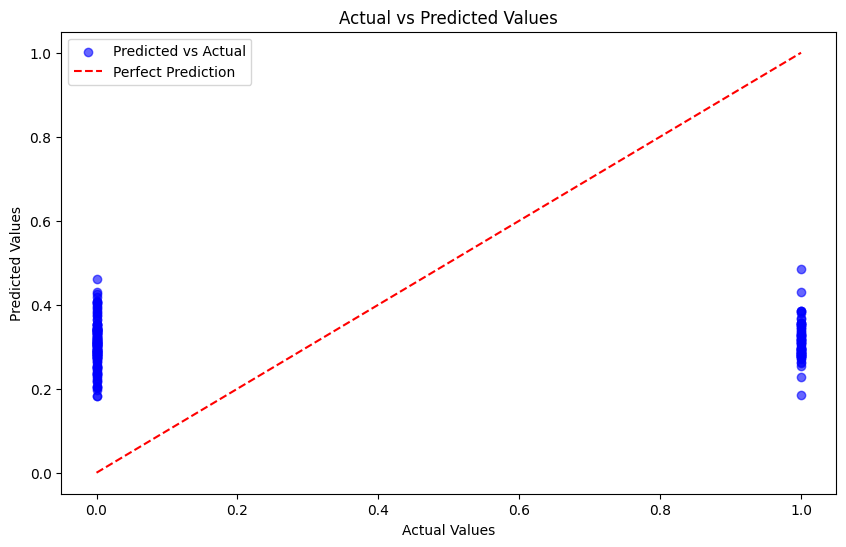

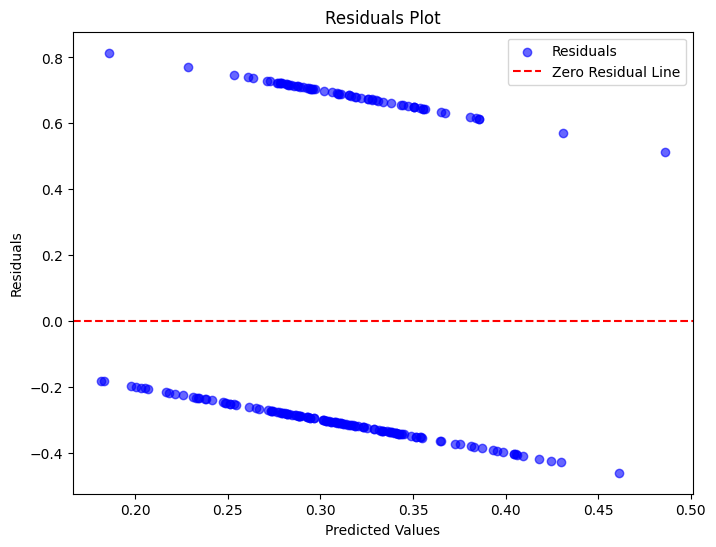

In [76]:
import matplotlib.pyplot as plt
import numpy as np

residuals = y_test - y_pred_stack

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))

# Plotting actual vs predicted
plt.scatter(y_test, y_pred_stack, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()

# Plot residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_stack, residuals, color='blue', alpha=0.6, label='Residuals')
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual Line')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.legend()
plt.show()


In [77]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

# Step 1: Load your dataset
df = df3

# Step 2: Separate features and target
X = df.drop("findings", axis=1)  # assuming 'findings' is the target
y = df["findings"]

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Step 4: Apply SMOTE to balance the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Step 5: Train the model
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train_resampled, y_train_resampled)

# Step 6: Make predictions
y_pred = model.predict(X_test)

# Step 7: Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))


Confusion Matrix:
[[114  28]
 [ 50  13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.80      0.75       142
           1       0.32      0.21      0.25        63

    accuracy                           0.62       205
   macro avg       0.51      0.50      0.50       205
weighted avg       0.58      0.62      0.59       205


Accuracy Score:
0.6195121951219512


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (confusion_matrix, 
                           classification_report, 
                           accuracy_score,
                           precision_recall_curve)  # Added missing import
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import VarianceThreshold  # Added to handle constant features

# Data cleaning - remove constant features first
constant_feature_remover = VarianceThreshold()
X_train_clean = constant_feature_remover.fit_transform(X_train)
X_test_clean = constant_feature_remover.transform(X_test)

# Handle NaN/inf
X_train_clean = np.nan_to_num(X_train_clean)
X_test_clean = np.nan_to_num(X_test_clean)

# Create improved pipeline
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif)),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

# Simplified parameter grid to reduce computation time
param_grid = {
    'selector__k': [20, 'all'],  # Reduced options
    'smote__k_neighbors': [3, 5],
    'rf__n_estimators': [200],
    'rf__max_depth': [10, None],
    'rf__class_weight': ['balanced', {0: 1, 1: 3}],
    'rf__min_samples_leaf': [1],
    'rf__max_features': ['sqrt']
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,  # Reduced from 5 to speed up
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

# Run grid search
print("Starting grid search...")
grid_search.fit(X_train_clean, y_train)
print("Grid search complete!")

# Get best model
best_model = grid_search.best_estimator_

# Make predictions
y_pred = best_model.predict(X_test_clean)
y_probs = best_model.predict_proba(X_test_clean)[:, 1]

# Find optimal threshold
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall)
f1_scores = np.nan_to_num(f1_scores)  # Handle division by zero
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
y_pred_optimized = (y_probs >= optimal_threshold).astype(int)

# Evaluation
print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nStandard Predictions:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nOptimized Threshold Predictions (Threshold = {:.3f}):".format(optimal_threshold))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimized))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimized))
print("Optimized Accuracy:", accuracy_score(y_test, y_pred_optimized))

Starting grid search...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
